# Examine figure stats

This is done after running `create_figures_batch.py`

In [167]:
save_dir = '~/Dropbox/jcdl_followup/synthetic_figures/' # where images are saved

In [219]:
import os
from glob import glob
import json
import pandas as pd
import re

save_dir = os.path.expanduser(save_dir)

In [169]:
# get jsons
img_files = glob(save_dir+'jsons/*.json')
img_files[:3]

['/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000121.json',
 '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000064.json',
 '/Users/jnaiman/Dropbox/jcdl_followup/synthetic_figures/jsons/Picture_000176.json']

In [170]:
npanels = []; ncols=[]; nrows=[]; filenames= []

for imgf in img_files:
    with open(imgf,'r') as f:
        data = json.load(f)
        data = json.loads(data)
    nr = data['figure']['nrows']
    nc = data['figure']['ncols']
    ncols.append(nc);nrows.append(nr)
    npanels.append(nc*nr)
    filenames.append(imgf)

df_figure = pd.DataFrame({'number of panels':npanels, 'number of columns':ncols,
                        'number of rows':nrows,
                        'filename':filenames})

In [171]:
print('there are a total of', len(df_figure), 'figures generated')
print('% of multipanel plots =', len(df_figure[df_figure['number of panels']>1])/len(df_figure)*100,
        '(total of', int(len(df_figure[df_figure['number of panels']>1])),')')

there are a total of 200 figures generated
% of multipanel plots = 41.0 (total of 82 )


In [172]:
df_figure['number of panels'].value_counts().sort_index()

number of panels
1     118
2      32
3       9
4      17
5       5
6       3
8       8
9       2
12      3
15      2
20      1
Name: count, dtype: int64

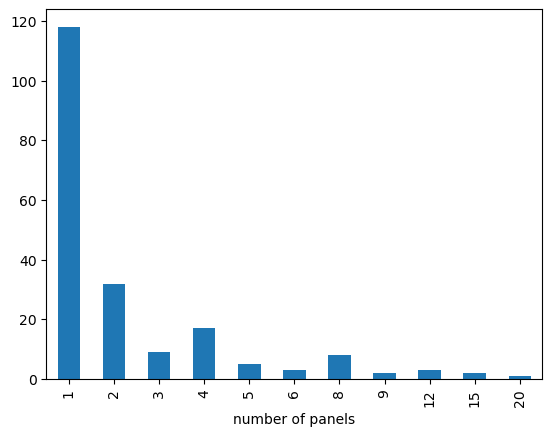

In [173]:
ax = df_figure['number of panels'].value_counts().sort_index().plot(kind='bar')


In [174]:
# remove a subset of single panel plots?
remove_singles = False
n_remove = 80
df_single_panel = df_figure[df_figure['number of panels'] == 1]
print('there are:', len(df_single_panel), 'single panel plots')
if remove_singles:
    df_s_remove = df_single_panel.sample(n=n_remove, replace=False)
    for i,d in df_s_remove.iterrows():
        #print(d['filename'])
        try:
            os.remove(d['filename'])
        except:
            print('could not remove:', d['filename'])
        try:
            os.remove(d['filename'].replace('/jsons/','/imgs/').removesuffix('.json')+'.jpeg') # also imgs
        except:
            print('could not remove:', d['filename'].replace('/jsons/','/imgs/').removesuffix('.json')+'.jpeg')
        try:
            os.remove(d['filename'].replace('/jsons/','/diags/').removesuffix('.json')+'.jpeg') # also imgs
        except:
            print('could not remove:', d['filename'].replace('/jsons/','/diags/').removesuffix('.json')+'.jpeg')


there are: 118 single panel plots


In [175]:
df_s_remove

,number of panels,number of columns,number of rows,filename
34,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
132,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
61,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
60,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
6,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
...,...,...,...,...
41,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
83,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
95,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...
105,1,1,1,/Users/jnaiman/Dropbox/jcdl_followup/synthetic...


## Investigate Titles

In [270]:
titles = []; xlabels=[]; ylabels=[]
pnums = []; fnums = []

for imgf in img_files:
    with open(imgf,'r') as f:
        data = json.load(f)
        data = json.loads(data)
    t=[];x=[];y=[]; p=[]
    for k,v in data.items():
        if 'plot' in k:
            p.append(int(k.replace('plot',''))) 
            for l,a in zip(['title', 'xlabel', 'ylabel'],[t,x,y]):
                if l in v:
                    a.append(v[l]['words'])
                else:
                    a.append('')
    # fill in full results
    for l in t:
        fnums.append(int(imgf.split('Picture_')[-1].removesuffix('.json')))
    titles.extend(t); xlabels.extend(x); ylabels.extend(y); pnums.extend(p)
    

title_words = []; xlabel_words = []; ylabel_words=[]
for ain,aout in zip([titles,xlabels,ylabels], [title_words,xlabel_words,ylabel_words]):
    for text in ain:
        if '$' in text:
            parts = re.split(r'(\$[^$]+\$)', text)
            parts = [p for p in parts if p.strip()]
            # then loop by spaces
            full_parts = []
            for p in parts:
                if '$' in p:
                    full_parts.append(p)
                else:
                    t = p.lstrip().rstrip().split(' ')
                    for tt in t:
                        if len(tt.replace(' ','')) > 0:
                            full_parts.append(tt)
        else:
            t = text.lstrip().rstrip().split(' ')
            full_parts = []
            for tt in t:
                if len(tt.replace(' ','')) > 0:
                    full_parts.append(tt)
            #if len(full_parts) == 0: # if no text...
        aout.append(full_parts)
    #import sys; sys.exit()
        

dfl = pd.DataFrame({'figure':fnums, 'plot':pnums, 
                    'title': titles, 'xlabel':xlabels, 'ylabel':ylabels, 
                    'title words':title_words, 'xlabel words':xlabel_words, 'ylabel words':ylabel_words})

In [271]:
dfl.head()

,figure,plot,title,xlabel,ylabel,title words,xlabel words,ylabel words
0,121,0,,Serve,Positions,[],[Serve],[Positions]
1,121,1,$P_{\rm rot} = 34.6\pm0.8$ Output Gps,STOCHASTIC,INSTABILITY,"[$P_{\rm rot} = 34.6\pm0.8$, Output, Gps]",[STOCHASTIC],[INSTABILITY]
2,64,0,,Facilities Success,Scenarios $J^j$ $J_B$,[],"[Facilities, Success]","[Scenarios, $J^j$, $J_B$]"
3,64,1,ARRIVAL TYPE $ u_{\rm 1c} = x + 0.25$,$r_0 \sim 5.5$ Coalescence,RELATIONSHIP EVOLUTION,"[ARRIVAL, TYPE, $ u_{\rm 1c} = x + 0.25$]","[$r_0 \sim 5.5$, Coalescence]","[RELATIONSHIP, EVOLUTION]"
4,176,0,DUST TRACERS ABSORBERS $\sim 10^{10}$,"$12\,405$ COMPARE $\psi_{max}$",phase target,"[DUST, TRACERS, ABSORBERS, $\sim 10^{10}$]","[$12\,405$, COMPARE, $\psi_{max}$]","[phase, target]"
